# AerisPlane — Flight Performance & Mission Analysis

This notebook demonstrates the `mission` module: drag polar fitting, power curves,
characteristic speeds, climb/glide performance, flight envelope, and mission energy budgets.

**What the mission module does:**
1. Fits a parabolic drag polar (CD = CD0 + k·CL²) from a few VLM evaluations
2. Computes power required P_R(V) and power available P_A(V) curves
3. Derives characteristic speeds: stall, best range, best endurance, max level
4. Calculates climb rate, service/absolute ceiling, and glide performance
5. Estimates max endurance and range from battery energy
6. Sweeps across altitudes to build a full flight envelope
7. Analyzes mission segments (climb, cruise, loiter, descent) for energy budget

In [1]:
import aerisplane as ap
from aerisplane import weights, mission
from aerisplane.mission import performance, envelope, analyze
from aerisplane.mission.performance import (
    fit_drag_polar, power_required, power_available,
    stall_speed, best_range_speed, best_endurance_speed, max_level_speed,
    rate_of_climb, max_rate_of_climb, glide_performance, max_endurance, max_range,
)
from aerisplane.mission.envelope import compute_envelope
from aerisplane.mission.segments import Mission, Climb, Cruise, Loiter, Descent, Return
from aerisplane.catalog.materials import carbon_fiber_tube, petg
import numpy as np
import matplotlib.pyplot as plt

## 1. Define the Aircraft

We’ll reuse a simple trainer-style aircraft with a rectangular wing, H-tail,
fuselage, and a full propulsion system (motor + prop + 4S LiPo + ESC).

In [2]:
# Structural components
cf_spar = ap.Spar(
    position=0.25, material=carbon_fiber_tube,
    section=ap.TubeSection(outer_diameter=0.012, wall_thickness=0.0015),
)
petg_skin = ap.Skin(material=petg, thickness=0.8e-3)

# Main wing: 1.5m span, 0.2m chord
main_wing = ap.Wing(
    name="main_wing",
    xsecs=[
        ap.WingXSec(xyz_le=[0.1, 0.0, 0.0], chord=0.2, spar=cf_spar, skin=petg_skin),
        ap.WingXSec(xyz_le=[0.1, 0.75, 0.0], chord=0.2, spar=cf_spar, skin=petg_skin),
    ],
    symmetric=True,
)

# Horizontal tail
htail = ap.Wing(
    name="htail",
    xsecs=[
        ap.WingXSec(xyz_le=[0.75, 0.0, 0.0], chord=0.12),
        ap.WingXSec(xyz_le=[0.75, 0.30, 0.0], chord=0.08),
    ],
    symmetric=True,
)

# Propulsion
motor = ap.Motor(name="2212-1100KV", kv=1100, resistance=0.028,
                 no_load_current=1.2, max_current=40.0, mass=0.060)
prop = ap.Propeller(diameter=0.254, pitch=0.127, mass=0.030)  # 10x5
battery = ap.Battery(name="4S 2200mAh", capacity_ah=2.2, nominal_voltage=14.8,
                     cell_count=4, c_rating=30.0, mass=0.200)
esc = ap.ESC(name="30A ESC", max_current=40.0, mass=0.035)
propulsion = ap.PropulsionSystem(
    motor=motor, propeller=prop, battery=battery, esc=esc,
    position=np.array([0.0, 0.0, 0.0]),
)

# Fuselage
fuselage = ap.Fuselage(
    name="fuselage",
    xsecs=[
        ap.FuselageXSec(x=0.0, radius=0.02),
        ap.FuselageXSec(x=0.15, radius=0.06),
        ap.FuselageXSec(x=0.70, radius=0.06),
        ap.FuselageXSec(x=0.95, radius=0.02),
    ],
    material=petg, wall_thickness=0.001,
)

aircraft = ap.Aircraft(
    name="TrainerPlane",
    wings=[main_wing, htail],
    fuselages=[fuselage],
    propulsion=propulsion,
    payload=ap.Payload(mass=0.100, cg=np.array([0.25, 0.0, 0.0]), name="FPV camera"),
)

# Weight analysis
weight_result = weights.analyze(aircraft)
print(f"Total mass:   {weight_result.total_mass * 1000:.0f} g")
print(f"Wing loading: {weight_result.wing_loading:.1f} g/dm\u00b2")
print(f"Wing area:    {aircraft.reference_area():.4f} m\u00b2")
print(f"Span:         {aircraft.reference_span():.2f} m")

Total mass:   1798 g
Wing loading: 59.9 g/dm²
Wing area:    0.3000 m²
Span:         1.50 m


## 2. Fit the Drag Polar

The drag polar CD = CD0 + k·CL² is fitted by running the VLM at 3 airspeeds.
Since VLM is inviscid, parasitic drag is estimated from turbulent flat-plate skin friction.

CD0:      0.01539
k:        0.04076
L/D max:  20.0
CL @ L/D max: 0.614
CL @ min power: 1.064


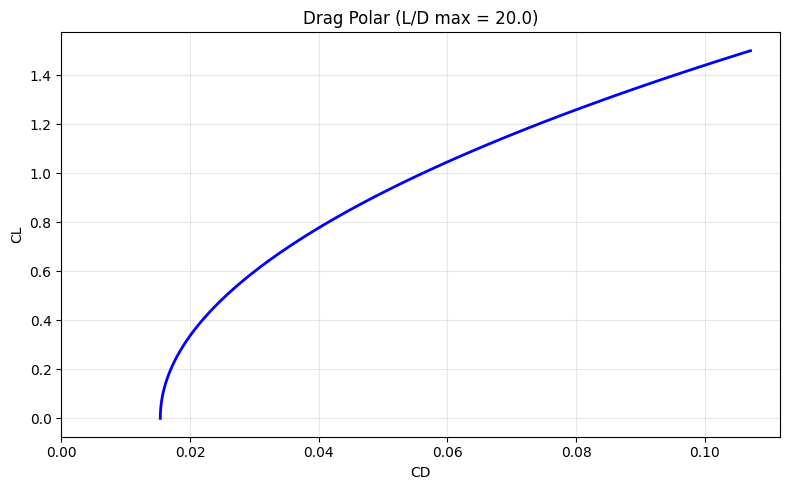

In [3]:
polar = fit_drag_polar(aircraft, weight_result, altitude=0.0)

print(f"CD0:      {polar.CD0:.5f}")
print(f"k:        {polar.k:.5f}")
print(f"L/D max:  {polar.ld_max():.1f}")
print(f"CL @ L/D max: {polar.cl_for_ld_max():.3f}")
print(f"CL @ min power: {polar.cl_for_min_power():.3f}")

# Plot the drag polar
cl_range = np.linspace(0, 1.5, 100)
cd_range = [polar.cd(cl) for cl in cl_range]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cd_range, cl_range, 'b-', lw=2)
ax.set_xlabel('CD')
ax.set_ylabel('CL')
ax.set_title(f'Drag Polar (L/D max = {polar.ld_max():.1f})')
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()

## 3. Power Curves

Power required follows the classic U-shape: high at low speed (induced drag)
and high at high speed (parasitic drag). Power available comes from the motor-prop system.

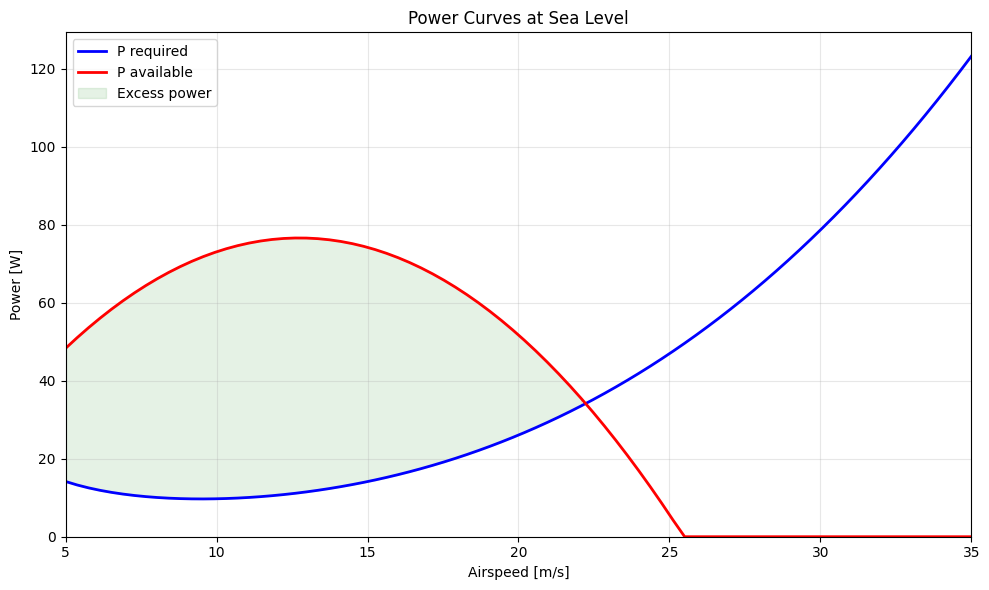

In [4]:
mass = weight_result.total_mass
V = np.linspace(5, 35, 80)
P_R = [power_required(v, polar, mass, altitude=0.0) for v in V]
P_A = [power_available(aircraft.propulsion, v, altitude=0.0) for v in V]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(V, P_R, 'b-', lw=2, label='P required')
ax.plot(V, P_A, 'r-', lw=2, label='P available')
ax.fill_between(V, P_R, P_A, where=[pa > pr for pa, pr in zip(P_A, P_R)],
                alpha=0.1, color='green', label='Excess power')
ax.set_xlabel('Airspeed [m/s]')
ax.set_ylabel('Power [W]')
ax.set_title('Power Curves at Sea Level')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(5, 35)
ax.set_ylim(bottom=0)
plt.tight_layout()

## 4. Characteristic Speeds

Key speeds derived from the drag polar and propulsion system.

In [5]:
S = aircraft.reference_area()
v_stall = stall_speed(mass, S, CL_max=1.4, altitude=0.0)
v_endurance = best_endurance_speed(polar, mass, altitude=0.0)
v_range = best_range_speed(polar, mass, altitude=0.0)
v_max = max_level_speed(polar, mass, aircraft.propulsion, altitude=0.0)

print(f"V_stall:          {v_stall:.1f} m/s  ({v_stall * 3.6:.1f} km/h)")
print(f"V_best_endurance: {v_endurance:.1f} m/s  ({v_endurance * 3.6:.1f} km/h)")
print(f"V_best_range:     {v_range:.1f} m/s  ({v_range * 3.6:.1f} km/h)")
if v_max is not None:
    print(f"V_max:            {v_max:.1f} m/s  ({v_max * 3.6:.1f} km/h)")
else:
    print("V_max:            N/A (insufficient power)")

V_stall:          8.3 m/s  (29.8 km/h)
V_best_endurance: 9.5 m/s  (34.2 km/h)
V_best_range:     12.5 m/s  (45.0 km/h)
V_max:            22.0 m/s  (79.2 km/h)


## 5. Climb & Glide Performance

In [6]:
# Climb
roc_max, v_y = max_rate_of_climb(polar, mass, aircraft.propulsion, altitude=0.0)
print(f"Max rate of climb: {roc_max:.1f} m/s at V_y = {v_y:.1f} m/s")

# Glide
gp = glide_performance(polar, mass, altitude=0.0)
print(f"\nBest glide ratio:  {gp.best_glide_ratio:.1f}")
print(f"Best glide speed:  {gp.best_glide_speed:.1f} m/s")
print(f"Min sink speed:    {gp.min_sink_speed:.1f} m/s")
print(f"Min sink rate:     {gp.min_sink_rate:.2f} m/s")
print(f"\nGlide from 100m:   {gp.best_glide_ratio * 100:.0f} m range")

Max rate of climb: 3.7 m/s at V_y = 12.0 m/s

Best glide ratio:  20.0
Best glide speed:  12.5 m/s
Min sink speed:    9.5 m/s
Min sink rate:     0.55 m/s

Glide from 100m:   1996 m range


## 6. Endurance & Range

In [7]:
endurance = max_endurance(polar, mass, aircraft.propulsion, altitude=0.0)
range_m = max_range(polar, mass, aircraft.propulsion, altitude=0.0)

print(f"Battery energy:  {aircraft.propulsion.battery.energy() / 3600:.1f} Wh")
print(f"Max endurance:   {endurance / 60:.1f} min (at V = {v_endurance:.1f} m/s)")
print(f"Max range:       {range_m / 1000:.1f} km  (at V = {v_range:.1f} m/s)")

Battery energy:  32.6 Wh
Max endurance:   26.6 min (at V = 9.5 m/s)
Max range:       19.1 km  (at V = 12.5 m/s)


## 7. Flight Envelope

Sweep performance across altitudes. The `compute_envelope()` function produces
an `EnvelopeResult` with arrays of speeds, climb rates, and ceilings.

In [8]:
env = compute_envelope(aircraft, weight_result)
print(env.report())

AerisPlane Flight Performance Envelope

Drag Polar
----------------------------------------
  CD0                0.01539
  k                  0.04076
  L/D max               20.0

Characteristic Speeds (sea level)
----------------------------------------
  Stall                  8.3  m/s
  Best endurance         9.5  m/s
  Best range            12.5  m/s
  Max speed             22.0  m/s

Climb Performance
----------------------------------------
  Max ROC (SL)           3.7  m/s
  V_y (SL)              12.0  m/s
  Service ceiling       3000  m
  Absolute ceiling      3000  m

Glide Performance
----------------------------------------
  Best glide L/D        20.0
  Best glide V          12.5  m/s
  Min sink rate         0.55  m/s

Endurance & Range
----------------------------------------
  Max endurance         26.6  min
  Max range             19.1  km


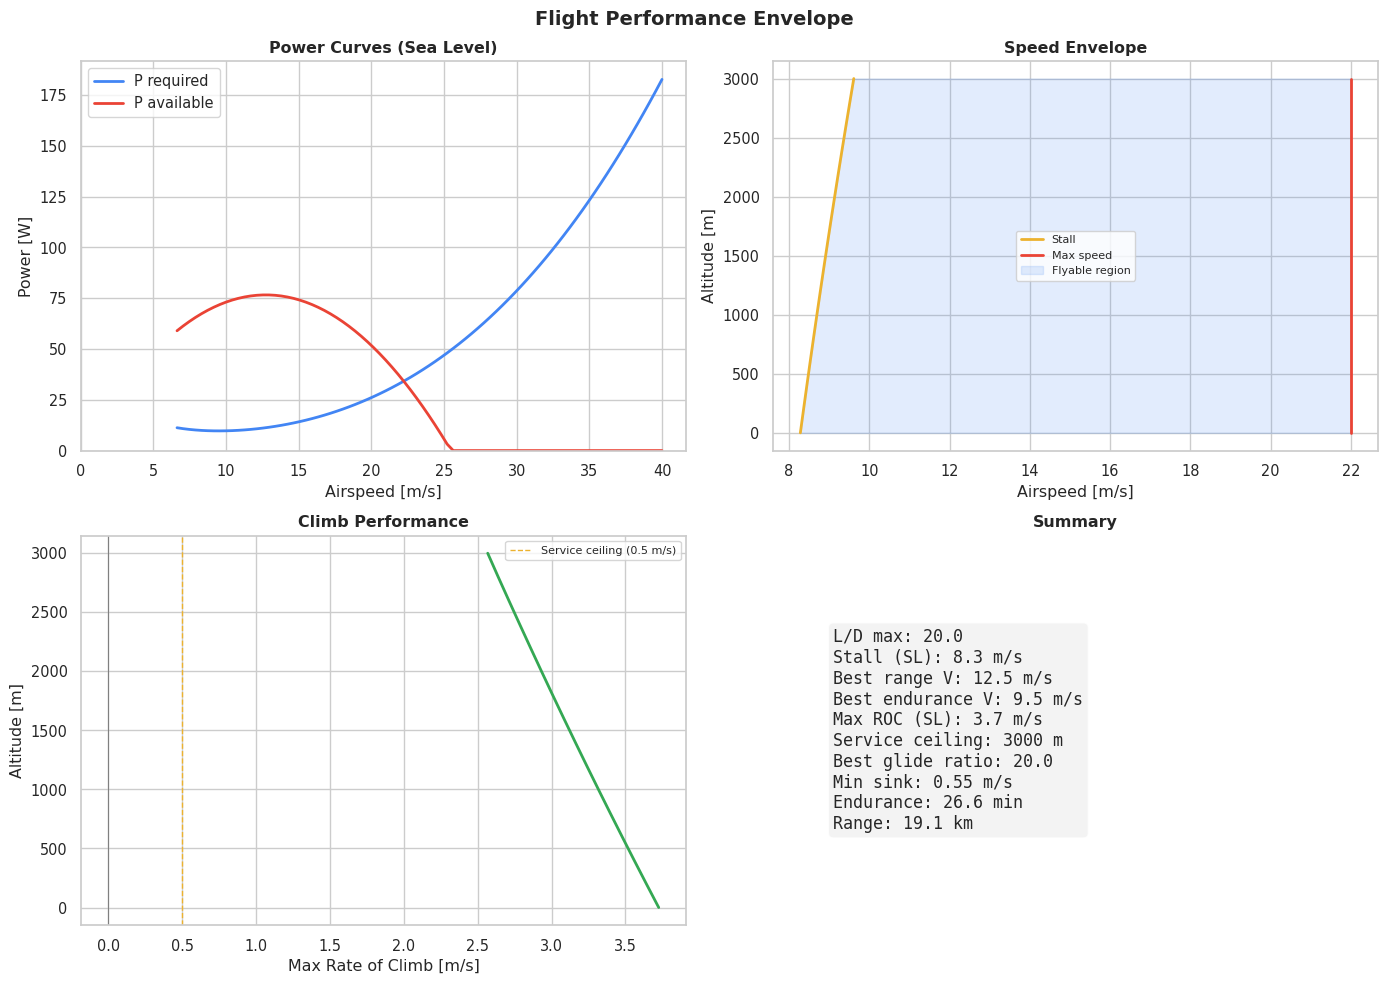

In [9]:
# Built-in 4-panel plot: power curves, speed envelope, ROC vs altitude, summary
fig = env.plot()
plt.show()

## 8. Mission Analysis

Define a mission as a sequence of segments and compute the energy budget.
Each segment type (Climb, Cruise, Loiter, Descent, Return) specifies the
flight condition, and the module computes duration, distance, and energy.

In [10]:
# Define a survey mission
survey_mission = Mission(segments=[
    Climb(to_altitude=100, climb_rate=2.0, velocity=12.0),
    Cruise(distance=3000, velocity=15.0, altitude=100.0),
    Loiter(duration=300, velocity=12.0, altitude=100.0),     # 5 min loiter
    Return(distance=3000, velocity=15.0, altitude=100.0),
    Descent(to_altitude=0.0, descent_rate=2.0, velocity=12.0),
])

result = analyze(aircraft, weight_result, survey_mission)
print(result.report())

AerisPlane Mission Analysis

Segment          Duration  Distance    Energy  Avg Power        Alt
---------------------------------------------------------------------------
climb                 50s      600m      4.5Wh     321.4W    0->100m
cruise               200s     3000m      5.5Wh      98.6W  100->100m
loiter               300s     3600m      6.2Wh      74.5W  100->100m
return               200s     3000m      5.5Wh      98.6W  100->100m
descent               50s      600m      0.5Wh      37.3W    100->0m
---------------------------------------------------------------------------
TOTAL                800s    10800m     22.1Wh

Battery energy:   32.6 Wh
Energy used:      22.1 Wh
Energy margin:    32.0%
Mission time:     13.3 min
Status:           FEASIBLE


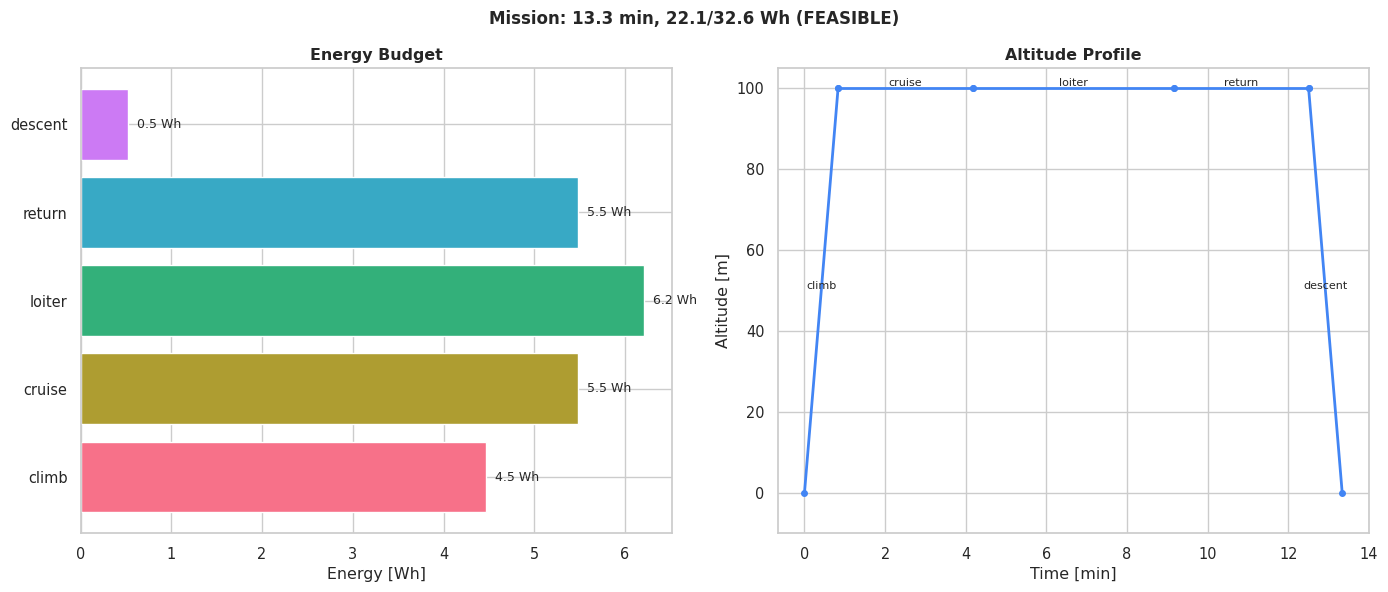

In [11]:
# Mission profile plot: energy bars + altitude profile
fig = result.plot()
plt.show()

## 9. Comparing Missions

Quickly evaluate different mission profiles to find the energy-optimal plan.

In [12]:
# Short sprint vs long loiter
sprint = Mission(segments=[
    Climb(to_altitude=50, climb_rate=3.0, velocity=15.0),
    Cruise(distance=8000, velocity=20.0, altitude=50.0),
    Descent(to_altitude=0.0),
])

loiter_mission = Mission(segments=[
    Climb(to_altitude=80, climb_rate=2.0, velocity=12.0),
    Loiter(duration=900, velocity=10.0, altitude=80.0),  # 15 min loiter
    Descent(to_altitude=0.0),
])

r_sprint = analyze(aircraft, weight_result, sprint)
r_loiter = analyze(aircraft, weight_result, loiter_mission)

print(f"{'Mission':<20} {'Time':>8} {'Distance':>10} {'Energy':>10} {'Margin':>8} {'Status':>10}")
print("-" * 70)
for name, r in [("Sprint", r_sprint), ("Long loiter", r_loiter), ("Survey", result)]:
    print(f"{name:<20} {r.total_time/60:>7.1f}m {r.total_distance/1000:>9.1f}km "
          f"{r.total_energy/3600:>9.1f}Wh {r.energy_margin*100:>6.1f}% "
          f"{'OK' if r.feasible else 'FAIL':>10}")

Mission                  Time   Distance     Energy   Margin     Status
----------------------------------------------------------------------
Sprint                   7.4m       8.6km      28.0Wh   14.0%         OK
Long loiter             16.3m      10.1km      22.2Wh   31.9%         OK
Survey                  13.3m      10.8km      22.1Wh   32.0%         OK
